<a href="https://colab.research.google.com/github/Jyoti-Yadav2/R-for-bioinformatics/blob/main/Computational_Gene_finding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#install R base
#Configure rpy2

In [ ]:
install.packages("BiocManager")
BiocManager::install(c("seqinr", "Biostrings", "rentrez"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'seqinr' 'Biostrings' 'rentrez'”
Old packages: 'callr', 'dbplyr', 'httr2', 'openssl', 'pak', 'pkgload', 'Rcpp',
  'rlang', 'rstudioapi', 'selectr', 'sessioninfo', 'shiny', 'tinytex', 'withr',
  'xfun', 'xml2', 'xtable', 'zip'



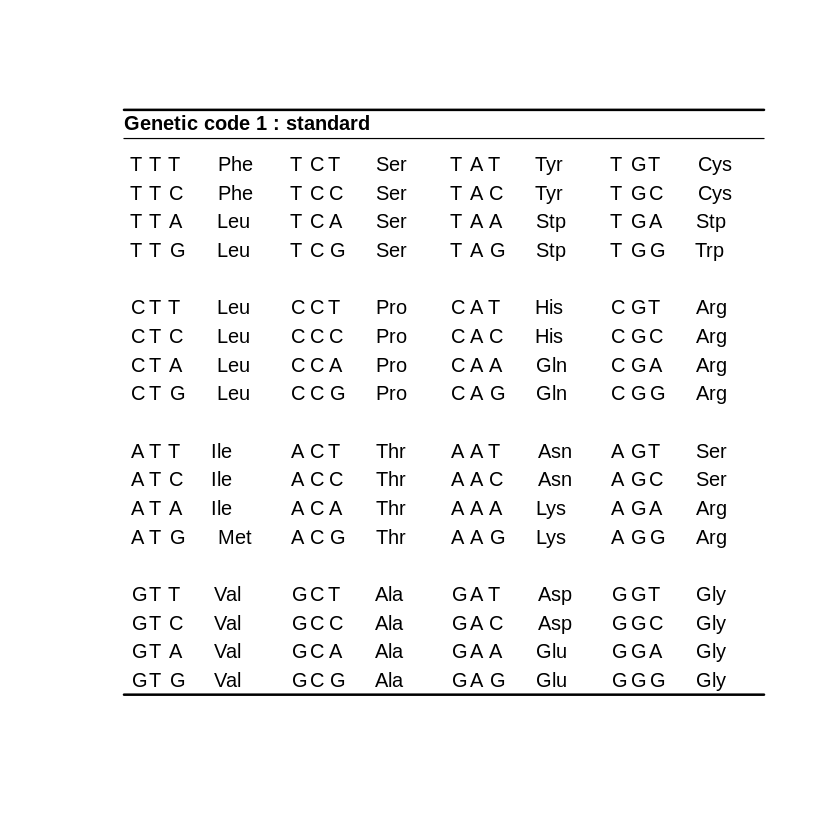

In [ ]:
library(seqinr)
tablecode()

In [ ]:
library(Biostrings)
s1 <- "aaaatgcagtaacccatgccc"
matchPattern("atg", s1) #Find all ATGs in seq s1

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

Views on a 21-letter BString subject
subject: aaaatgcagtaacccatgccc
views:
      start end width
  [1]     4   6     3 [atg]
  [2]    16  18     3 [atg]

In [ ]:
findPotentialStartsAndStops <- function (sequence)
{
  # Define a vector with the sequences of potential start and stop codons
  codons <- c("atg", "taa", "tag", "tga")
  positions <-numeric()
  types <- character()
  # Find the number of occurrences of each type of potential start or stop codon
  for (i in 1:4)
  {
  codon <- codons[i]
  # Find all occurrences of codon "codon" in sequence "sequence"
  occurrences <- matchPattern (codon, sequence)
  # Find the start positions of all occurrences of "codon" in sequence
  codonpositions <- start(occurrences)
  # Find the total number of potential start and stop codons in sequence
  numoccurrences <- length (codonpositions)
  if (i == 1)
  {
    # Make a copy of vector "codonpositions" called "positions"
    positions = codonpositions
    # Make a vector "types" containing
    types = rep(codon, numoccurrences)
  }
  else
  {
    #Add the vector "codonpositions" to the end of vector "positions":
    positions <- c(positions, codonpositions)
    # Add the vector "rep(codon, numoccurrences)" to the end of vector "types":
    types <-  c(types, rep(codon, numoccurrences))
  }
  }
    # Sort the vectors "positions" and "types" in order of position along the
    indices <- order(positions)
    positions <- positions [indices]  # Return a list variable including
    types <- types [indices]
    mylist <- list (positions, types)
    return (mylist)
}
s1 <- "aaaatgcagtaacccatgccc";
findPotentialStartsAndStops(s1)

[[1]]
[1]  4 10 16

[[2]]
[1] "atg" "taa" "atg"

In [ ]:
library(rentrez)
library(Biostrings)

# Fetch the FASTA record from NCBI using rentrez
fasta_record <- entrez_fetch(db="nuccore", id="NC_001477", rettype="fasta", retmode="text")

# Parse the FASTA record to extract the raw sequence string
# This splits the string by newlines, removes the header line (starting with '>'),
# and then concatenates the remaining parts (the sequence) into a single string.
sequence_lines <- unlist(strsplit(fasta_record, "\n"))
sequence_string <- paste(sequence_lines[-grep("^>", sequence_lines)], collapse = "")

# Convert the sequence string into a DNAString object for Biostrings compatibility
dengueseq <- DNAString(sequence_string)

In [ ]:
dengueseqstart <- dengueseq[1:500]
length(dengueseqstart)

[1] 500

In [ ]:
dengueseqstartstring <- c2s(tolower(dengueseqstart))
dengueseqstartstring

[1] "agttgttagtctacgtggaccgacaagaacagtttcgaatcggaagcttgcttaacgtagttctaacagttttttattagagagcagatctctgatgaacaaccaacggaaaaagacgggtcgaccgtctttcaatatgctgaaacgcgcgagaaaccgcgtgtcaactgtttcacagttggcgaagagattctcaaaaggattgctttcaggccaaggacccatgaaattggtgatggcttttatagcattcctaagatttctagccatacctccaacagcaggaattttggctagatggggctcattcaagaagaatggagcgatcaaagtgttacggggtttcaagaaagaaatctcaaacatgttgaacataatgaacaggaggaaaagatctgtgaccatgctcctcatgctgctgcccacagccctggcgttccatctgaccacccgagggggagagccgcacatgatagttagcaagcaggaaagaggaaaat"

In [ ]:
findPotentialStartsAndStops(dengueseqstartstring)

[[1]]
 [1]   7  53  58  64  78  93  95  96 137 141 224 225 234 236 246 255 264 295 298
[20] 318 365 369 375 377 378 399 404 413 444 470 471 474 478

[[2]]
 [1] "tag" "taa" "tag" "taa" "tag" "tga" "atg" "tga" "atg" "tga" "atg" "tga"
[13] "tga" "atg" "tag" "taa" "tag" "tag" "atg" "atg" "atg" "tga" "taa" "atg"
[25] "tga" "tga" "atg" "atg" "tga" "atg" "tga" "tag" "tag"

In [ ]:
substring(dengueseqstartstring, 137, 143)

[1] "atgctga"

**Find open reading frames on forward strand of an DNA sequence**

In [ ]:
plotPotentialStartsAndStops <- function (sequence)
{
  # Define a vector with the sequences of potential start and stop codons
  codons <- c("atg", "taa", "tag", "tga")
  # Find the number of occurrences of each type of potential start or stop codon
  for (i in 1:4)
  {
  codon <- codons [i]
  # Find all occurrences of codon "codon" in sequence "sequence"
  occurrences <- matchPattern(codon, sequence)
  # Find the start positions of all occurrences of "codon" in sequence "sequence"
  codonpositions <- start(occurrences)
  # Find the total number of potential start and stop codons in sequence
  numoccurrences <- length(codonpositions)
  if (i == 1)
  {
    # Make a copy of vector "codonpositions" called "positions"
    positions <- codonpositions
    types <- rep (codon, numoccurrences)
    }
    else
    {
      # Add the vector "codonpositions" to the end of vector "positions":
      positions <- append(positions, codonpositions,after=length(positions))
      # Add the vector "rep(codon, numoccurrences)" to the end of vector
      types <- append(types, rep(codon, numoccurrences), after=length(types))
    }
}
# Sort the vectors "positions" and "types" in order of position along the,
indices <- order (positions)
positions <- positions [indices]
types <- types [indices]
# Make a plot showing the positions of the start and stop codons in the input
# Draw a line at y=0 from 1 to the length of the sequence:
x <- c(1, nchar (sequence))
y <- c(0,0)
plot(x, y, ylim=c(0,3), type="l", axes=FALSE, xlab="Nucleotide",
                  ylab="Reading frame",
                  main="Predicted start (red) and stop (blue) codons")
segments (1,1,nchar(sequence), 1)
segments (1,2, nchar(sequence), 2)
# Add the x-axis at y=0:
axis (1, pos=0)
# Add the y-axis labels:
text (0.9,0.5,"+1")
text (0.9,1.5, "+2")
text (0.9,2.5,"+3")
# Draw in each predicted start/stop codon:
numcodons <- length (positions)
for (i in 1:numcodons)
{
  position <- positions [i]
  type <- types[i]
  remainder <- (position-1) %% 3
  if (remainder == 0) # +1 reading frame
  {
    if (type == "atg") { segments (position, 0,position, 1,lwd=1, col="red") }
    else { segments (position, 0, position, 1,lwd=1, col="blue")}
  }
  else if (remainder == 1)
  {
    if (type == "atg") { segments (position,1,position, 2,lwd=1,col="red") }
    else { segments (position, 1,position, 2,lwd=1, col="blue")}
  }
  else if (remainder == 2)
  {
    if (type == "atg") { segments (position, 2,position, 3,lwd=1,col="red") }
    else { segments (position, 2, position, 3, lwd=1, col="blue")}
  }
}
}

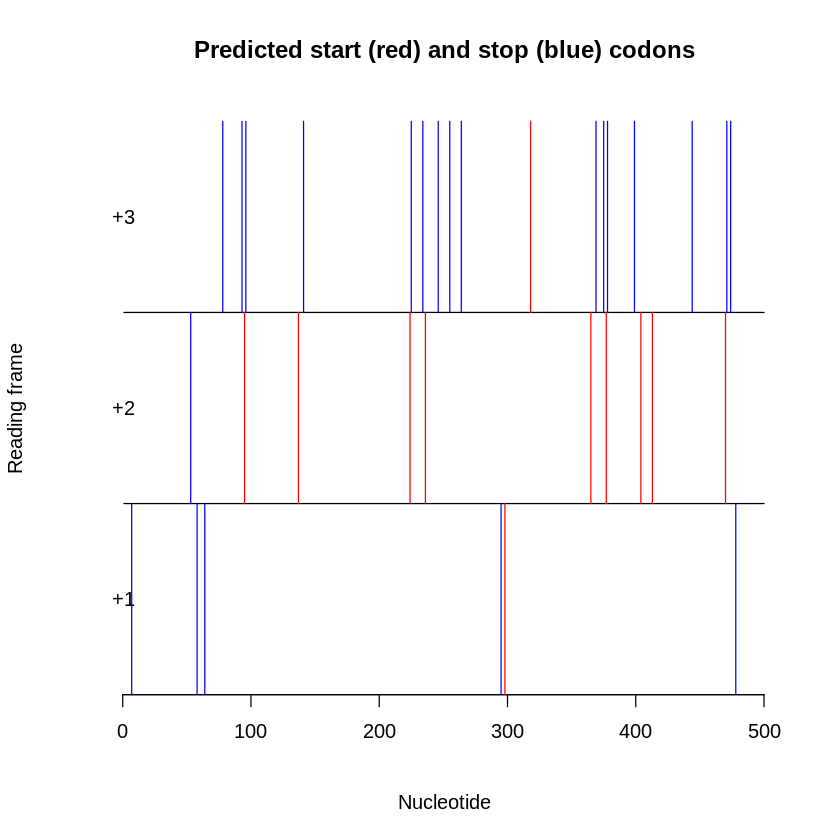

In [ ]:
plotPotentialStartsAndStops(dengueseqstartstring)

In [ ]:
findORFsinSeq <- function(sequence)
{
  require (Biostrings)
  # Make vectors "positions" and "types" containing information on thepositions of o ATGs in the sequence:
  mylist <- findPotentialStartsAndStops (sequence)
  positions <- mylist [[1]]
  types <- mylist [[2]]
  # Make vectors "orfstarts" and "orfstops" to store the predicted start and stop codons of ORFs
  orfstarts <- numeric()
  orfstops <- numeric()
  # Make a vector "orflengths" to store the lengths of the ORFs
  orflengths <- numeric()
  #Print out the positions of ORFs in the sequence:
  # Find the length of vector "positions"
  numpositions <- length (positions)
  # There must be at least one start codon and one stop codon to have an ORF.
  if (numpositions >= 2)
  {
    for (i in 1: (numpositions-1))
    {
      posi <- positions[i]
      typei <- types [i]
      found <- 0
      while (found == 0)
      {
        for (j in (i+1): numpositions)
        {
          posj <- positions[j]
          typej <- types [j]
          posdiff <- posj - posi
          posdiffmod3 <- posdiff %% 3
          # Add in the length of the stop codon
          orflength <- posj - posi + 3
          if (typei == "atg" && (typej == "taa" ||typej == "tga" ||
            typej == "tag") && posdiffmod3 == 0)
            {
              #Check if we have already used the stop codon at posj+2 in an ORF
              numorfs <- length(orfstops)
              usedstop <- -1
              if (numorfs > 0)
              {
                for (k in 1:numorfs)
                {
                  orfstopk <- orfstops [k]
                  if (orfstopk == (posj + 2)) { usedstop <- 1 }
                }
              }
              if (usedstop == -1)
              {
              orfstarts <- append(orfstarts, posi,after=length(orfstarts))
              orfstops <- append(orfstops, posj+2, after=length(orfstops))
              # Including the stop codon.
              orflengths <- append(orflengths, orflength,after=length(orflengths))
            }
            found <- 1
            break
        }
        if (j == numpositions) { found <- 1 }
      }
    }
  }
}
# Sort the final ORFs by start position:
indices <- order(orfstarts)
orfstarts <- orfstarts [indices]
orfstops <- orfstops [indices]
# Find the lengths of the ORFs that we have
orflengths <- numeric()
numorfs <- length(orfstarts)
for (i in 1:numorfs)
{
  orfstart <- orfstarts [i]
  orfstop <- orfstops[i]
  orflength <- orfstop - orfstart + 1
  orflengths <- append(orflengths, orflength, after=length(orflengths))
}
mylist <- list(orfstarts, orfstops, orflengths)
return (mylist)
}

In [ ]:
s1 <- "aaaatgcagtaacccatgccc"
findORFsinSeq(s1)

[[1]]
[1] 4

[[2]]
[1] 12

[[3]]
[1] 9

In [ ]:
findORFsinSeq(dengueseqstartstring)

[[1]]
[1] 298 318

[[2]]
[1] 480 371

[[3]]
[1] 183  54

In [ ]:
plotORFsinSeq <- function(sequence)
{
  # Make vectors "positions" and "types" containing information on positions of ATGs in the sequence:
  mylist <- findPotentialStartsAndStops (sequence)
  positions <- mylist [[1]]
  types <- mylist [[2]]
  # Make vectors "orfstarts" and "orfstops" to store the predicted start and stop
  orfstarts <- numeric()
  orfstops <- numeric()
  # Make a vector "orflengths" to store the lengths of the ORFs
  orflengths <- numeric()
  # Print out the positions of ORFs in the sequence:
  numpositions <- length (positions)
  # There must be at least one start codon
  if (numpositions >= 2)
  {
    for (i in 1: (numpositions-1))
    {
      posi <- positions [i]
      typei <- types [i]
      found <- 0
      while (found == 0)
      {
        for (j in (i+1): numpositions)
        {
          posj <- positions [j]
          typej <- types[j]
          posdiff <- posj - posi
          posdiffmod3 <- posdiff %% 3
          orflength <- posj - posi + 3 # Add in the length of the stop codon
          if (typei == "atg" && (typej == "taa" || typej == "tag" ||
            typej == "tga") && posdiffmod3 == 0)
            {
              #Check if we have already used the stop codon at posj+2 in an,ORF
              numorfs <- length(orfstops)
              usedstop <- -1
              if (numorfs > 0)
              {
                for (k in 1:numorfs)
                {
                  orfstopk <- orfstops [k]
                  if (orfstopk ==(posj + 2)) { usedstop <- 1}
                }
              }
              if (usedstop == -1)
              {
                orfstarts <- append(orfstarts, posi, after=length(orfstarts))
                orfstops <- append(orfstops, posj+2, after=length(orfstops))
                # Including the stop codon.
                orflengths <- append(orflengths, orflength, after=length(orflengths))
              }
              found <- 1
              break
            }
            if (j == numpositions) { found <- 1 }
        }
      }
    }
  }
  # Sort the final ORFs by start position:
  indices <- order(orfstarts)
  orfstarts <- orfstarts[indices]
  orfstops <- orfstops[indices]
  # Make a plot showing the positions of ORFs in the input sequence:
  # Draw a line at y=0 from 1 to the length of the sequence:
  x <- c(1, nchar(sequence))
  y <- c(0,0)
  plot (x, y, ylim=c(0,3), type="l", axes=FALSE, xlab="Nucleotide", ylab=
    "Reading frame", main="Predicted ORFs")
    segments (1,1,nchar(sequence),1)
    segments (1,2, nchar(sequence), 2)
    # Add the x-axis at y=0:
    axis (1, pos=0)
    # Add the y-axis labels:
    text (0.9,0.5, "+1")
    text (0.9,1.5,"+2")
    text (0.9,2.5,"+3")
    # Make a plot of the ORFs in the sequence:
    numorfs <- length (orfstarts)
    for (i in 1:numorfs)
    {
      orfstart <- orfstarts [i]
      orfstop <- orfstops [i]
      remainder <- (orfstart-1) %% 3
      if (remainder == 0) # +1 reading frame
      {
        rect (orfstart, 0, orfstop, 1, col="cyan", border="black")
      }
      else if (remainder == 1)
      {
        rect (orfstart,1,orfstop, 2, col="cyan", border="black")
      }
      else if (remainder == 2)
      {
        rect (orfstart,2, orfstop, 3, col="cyan", border="black")
      }
    }
}

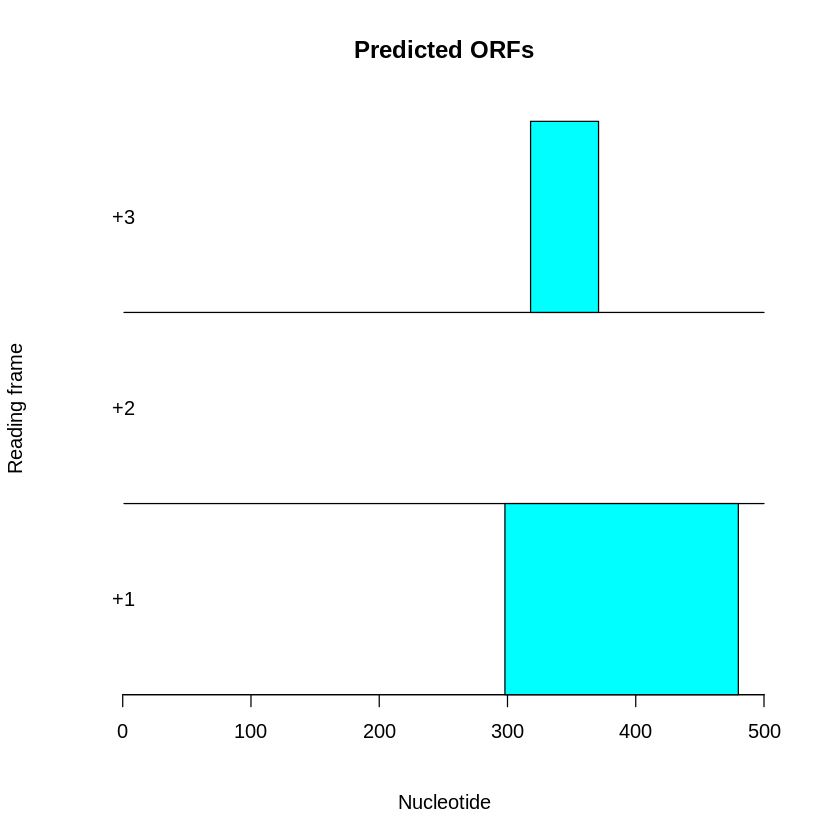

In [ ]:
plotORFsinSeq(dengueseqstartstring)

Predicting protein seq for sn ORF

In [ ]:
s1 <- "aaaatgcagtaacccatgccc"
myorf <- substring(s1,4,12)
myorf

[1] "atgcagtaa"

In [ ]:
myorfvector <- s2c(myorf)
myorfvector
seqinr::translate(myorfvector)

[1] "a" "t" "g" "c" "a" "g" "t" "a" "a"

[1] "M" "Q" "*"

In [ ]:
forward <- "AAAATGCTTAAACCATTGCCC"
forwardvector <- s2c(forward) # Convert the string of characters to vector
# Print out the vector containing the forward strand sequence
forwardvector
# Find the reverse strand sequence
reversevector <- rev (comp(forwardvector))
reversevector
reverse <- c2s (reversevector) # Convert the vector to a string of characters
reverse
complement <- comp(forwardvector)
reversevector <- rev(complement)

[1] "A" "A" "A" "A" "T" "G" "C" "T" "T" "A" "A" "A" "C" "C" "A" "T" "T" "G" "C"
[20] "C" "C"

[1] "g" "g" "g" "c" "a" "a" "t" "g" "g" "t" "t" "t" "a" "a" "g" "c" "a" "t" "t"
[20] "t" "t"

[1] "gggcaatggtttaagcatttt"

In [ ]:
findORFsinSeq(reverse)

[[1]]
[1] 6

[[2]]
[1] 14

[[3]]
[1] 9

In [ ]:
generateSeqsWithMultinomialModel <- function (inputsequence, X)
{
  # Change the input sequence into a vector of letters
  require("seqinr") # This function requires the the SeginR package.
  inputsequencevector <- s2c (inputsequence)
  # Find the frequencies of the letters in the input sequence "inputsequencevector":
  mylength <- length(inputsequencevector)
  mytable <- table(inputsequencevector)
  # Find the names of the letters in the sequence
  letters <- rownames (mytable)
  numletters <- length(letters)
  probabilities <- numeric() # Make a vector to store the probabilities of letters
  for (i in 1:numletters)
  {
    letter <- letters [i]
    count <- mytable [[i]]
    probabilities [i] <- count/mylength
    }
    # Make X random sequences using the multinomial model with probabilities
    seqs <- character(X) # Initialize as character vector, not numeric
    for (j in 1:X)
    {
      seq <- sample (letters, mylength, rep=TRUE, prob=probabilities)
      # sample with replacement
      seq <- c2s (seq)
      seqs [j] <- seq
    }
    # Return the vector of random sequences
    return (seqs)
}

In [ ]:
dengueseqstartstring <- tolower(c2s(dengueseqstartstring))
mylist <- findORFsinSeq(dengueseqstartstring)
orflengths <- mylist[[3]]
randseqs <- generateSeqsWithMultinomialModel(dengueseqstartstring,10)
randseqorflengths <- numeric()
for (i in 1:10)
{
  randomseq <- randseqs[i]
  mylist_rand <- findORFsinSeq(randomseq)
  lengths <- mylist_rand[[3]]
  randseqorflengths <- append(randseqorflengths, lengths,
  after=length(randseqorflengths))
}

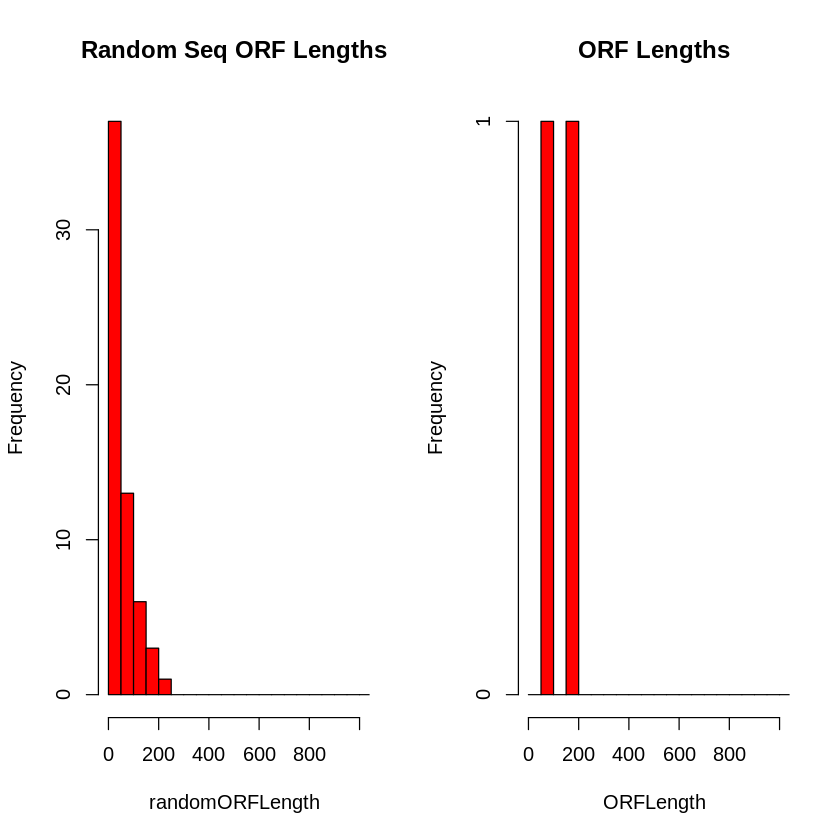

In [ ]:
par(mfrow = c(1,2)) # Make picture with two plots side-by-side(one row, two columns)
bins <- seq(0,11000,50) # Use a common bins definition that spans the full potential range

hist(randseqorflengths, breaks=bins, col="red", xlim=c(0, 1000), main="Random Seq ORF Lengths", xlab="randomORFLength")
hist(orflengths, breaks=bins, col="red", xlim=c(0,1000), main="ORF Lengths", xlab="ORFLength")

In [ ]:
max(randseqorflengths)

[1] 246

In [ ]:
summary(orflengths > 342)

   Mode   FALSE 
logical       2 

In [ ]:
quantile(randseqorflengths, probs=c(0.99))

99% 
201.75